In [1]:
from models.models import train_model_on_named_experiment
import os
from utils.defaults import AML_OUTPUTS_DIR

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


## Training Models:

#### Implemented Models:
| Model Class | Model Description | 
|------------|--------------------|  
| `AE` | Autoencoder | 
| `AEC`| Autoencoder Classifier |
| `scMEDAL-FE` | Domain Adversarial Autoencoder |
| `scMEDAL-FEC`| Domain Adversarial Autoencoder Classifier |
| `scMEDAL-RE`| Domain Enhancing Autoencoder Classifier | 

#### Named Experiments:
| Valid Named Experiment | Dataset |  n_clusters | n_pred |
|------------------------|---------|-------------|--------|
| `AML`| Acute Myeloid Leukemia | 19 | 21 |
| `ASD`| Autism Spectrum Disorder | 31 | 17 | 
| `HH` | Healthy Heart | 147 | 13 | 

**Note:** If training on other datasets, the configs will need to be passed in as dictionaries to `model_kwargs` and `train_kwargs`.

`quick` is a boolean flag that can be passed to `train_kwargs` which shortens training to only 1 fold for 3 epochs.

In [1]:
from utils.defaults import AML_OUTPUTS_DIR
import os
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_get_cf_batch-False_2025-07-03_17-56",
    #"ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_2025-06-26_20-03",
    #"aec":"run_crossval_n_latent_dims-2_layer_units-512-132_n_pred-21_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_2025-06-26_20-21",
    #"scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-42",
    #"scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-53",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-2_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-27_10-17",
    #"scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-03_17-28"
}
model_folder_dict = {k:os.path.join(AML_OUTPUTS_DIR, "latent_space", "log_transformed_2916hvggenes",k, v) for k, v in model_folder_dict.items()}

mec_aml = train_model_on_named_experiment("MEC", "AML", 
                                    train_kwargs={"quick":True, "results_path_dict":model_folder_dict, },
                                    model_kwargs={"models_list":list(model_folder_dict.keys()), "get_pca":True,
                                                   #"latent_keys_config":{"fe_latent":"ae_latent", "re_latent":"latent"}}
                                                "latent_keys_config":{"fe_latent":"X_pca", "re_latent":"latent"}}
                                )

NameError: name 'train_model_on_named_experiment' is not defined

In [ ]:
model_folder_dict = {
    #"ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_get_cf_batch-False_2025-07-03_17-56",
    #"ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-2_2025-06-26_20-03",
    #"aec":"run_crossval_n_latent_dims-2_layer_units-512-132_n_pred-21_use_batch_norm-True_scaling-min_max_model_type-aec_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_2025-06-26_20-21",
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-59",
    #"scmedalfec":"run_crossval_loss_gen_weight-1_loss_recon_weight-2000_loss_class_weight-1_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfec_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-06-26_20-53",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-59",
    #"scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-03_17-28"
}
model_folder_dict = {k:os.path.join(AML_OUTPUTS_DIR, "latent_space", "log_transformed_2916hvggenes",k, v) for k, v in model_folder_dict.items()}
 
mec_aml = train_model_on_named_experiment("MEC", "AML", 
                                    train_kwargs={"quick":True, "results_path_dict":model_folder_dict, },
                                    model_kwargs={"models_list":list(model_folder_dict.keys()),# "get_pca":True,
                                                   "latent_keys_config":{"fe_latent":"scmedalfe_latent", "re_latent":"scmedalre_latent"}}
                                                #"latent_keys_config":{"fe_latent":"X_pca", "re_latent":"re_latent"}}
                                )

Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits
Save model set to: True
Number of batches: 19
Ordered batches (donors): ['AML1012', 'AML210A', 'AML328', 'AML329', 'AML419A', 'AML420B', 'AML475', 'AML556', 'AML707B', 'AML870', 'AML916', 'AML921A', 'BM1', 'BM2', 'BM3', 'BM4', 'BM5', 'MUTZ3', 'OCI']
{'scmedalfe': '/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/latent_space/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-59', 'scmedalre': '/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/latent_space/log_transformed_2916hvggenes/scmedalre/run_crossval_loss_recon_weight-110.

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/val
X.shape before scaling (7684, 2916)
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/test


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


X.shape before scaling (7684, 2916)
Batches available:  ['AML1012' 'AML210A' 'AML328' 'AML329' 'AML419A' 'AML420B' 'AML475'
 'AML556' 'AML707B' 'AML870' 'AML916' 'AML921A' 'BM1' 'BM2' 'BM3' 'BM4'
 'BM5' 'MUTZ3' 'OCI']
Key not found: fe_latent_train in adata_dict['train'].obsm
Key not found: fe_latent_val in adata_dict['val'].obsm
Key not found: fe_latent_test in adata_dict['test'].obsm
Key not found: re_latent_train in adata_dict['train'].obsm
Key not found: re_latent_val in adata_dict['val'].obsm
Key not found: re_latent_test in adata_dict['test'].obsm
inputs: {'train': {}, 'val': {}, 'test': {}}
model params <utils.model_train_utils.ModelManager.Namespace object at 0x2aae4eab8ca0>
{'name': 'mec', 'n_latent_dims': 50, 'layer_units': [8, 4], 'n_pred': 21}
{'optimizer': <keras.src.optimizers.legacy.adam.Adam object at 0x2aae4eaa5c40>, 'loss': <keras.src.losses.CategoricalCrossentropy object at 0x2aae4eaa5c70>, 'loss_weights': 1, 'metrics': [<keras.src.metrics.accuracy_metrics.Categorica

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Tue Jul  8 17:18:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:03:00.0 Off |                    0 |
| N/A   33C    P0             30W /  250W |    1212MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

TypeError: in user code:

    File "/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/engine/training.py", line 1338, in train_function  *
        return step_function(self, iterator)
    File "/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/engine/training.py", line 1322, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/engine/training.py", line 1303, in run_step  **
        outputs = model.train_step(data)
    File "/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/engine/training.py", line 1080, in train_step
        y_pred = self(x, training=True)
    File "/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/utils/traceback_utils

In [7]:
ae_aml = train_model_on_named_experiment("ae", "HH", train_kwargs={"quick":True})

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/HealthyHeart_data/log_transformed_3000hvggenes/splits
Save model set to: True
Number of batches: 147
Ordered batches (donors): ['H0015_LA_new', 'H0015_LV', 'H0015_RA', 'H0015_RV', 'H0015_apex', 'H0015_septum', 'H0020_LA_new', 'H0020_LV', 'H0020_RA', 'H0020_RV', 'H0020_apex', 'H0020_septum', 'H0025_LA', 'H0025_LV', 'H0025_RA', 'H0025_RV', 'H0025_apex', 'H0025_septum', 'H0026_LA', 'H0026_LV_V3', 'H0026_RA', 'H0026_RV', 'H0026_apex', 'H0026_septum2', 'H0035_LA', 'H0035_LV', 'H0035_RA', 'H0035_RV', 'H0035_apex', 'H0035_septum', 'H0037_Apex', 'H0037_LA_corr', 'H0037_LV', 'H0037_RA_corr', 'H0037_RV', 'H0037_septum', 'HCAHeart7606896', 'HCAHeart7656534', 'HCAHeart7656535', 'HCAHeart7656536', 'HCAHeart7656537', 'HCAHeart7656538', 'HCAHeart7656539', 'HCAHeart7664652', 'HCAHeart7664653', 'HCAHeart7664654', 'HCAHeart7698015', 'HCAHeart7698016', 'HCAHeart7698017', 'HCAHeart7702873', 'HCAHear

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/HealthyHeart_data/log_transformed_3000hvggenes/splits/split_1/val
X.shape before scaling (97227, 3000)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/HealthyHeart_data/log_transformed_3000hvggenes/splits/split_1/test
X.shape before scaling (97227, 3000)


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


loaded adata, adata_dict keys check: dict_keys(['train', 'val', 'test'])
Batches available:  ['H0015_LA_new' 'H0015_LV' 'H0015_RA' 'H0015_RV' 'H0015_apex'
 'H0015_septum' 'H0020_LA_new' 'H0020_LV' 'H0020_RA' 'H0020_RV'
 'H0020_apex' 'H0020_septum' 'H0025_LA' 'H0025_LV' 'H0025_RA' 'H0025_RV'
 'H0025_apex' 'H0025_septum' 'H0026_LA' 'H0026_LV_V3' 'H0026_RA'
 'H0026_RV' 'H0026_apex' 'H0026_septum2' 'H0035_LA' 'H0035_LV' 'H0035_RA'
 'H0035_RV' 'H0035_apex' 'H0035_septum' 'H0037_Apex' 'H0037_LA_corr'
 'H0037_LV' 'H0037_RA_corr' 'H0037_RV' 'H0037_septum' 'HCAHeart7606896'
 'HCAHeart7656534' 'HCAHeart7656535' 'HCAHeart7656536' 'HCAHeart7656537'
 'HCAHeart7656538' 'HCAHeart7656539' 'HCAHeart7664652' 'HCAHeart7664653'
 'HCAHeart7664654' 'HCAHeart7698015' 'HCAHeart7698016' 'HCAHeart7698017'
 'HCAHeart7702873' 'HCAHeart7702874' 'HCAHeart7702875' 'HCAHeart7702876'
 'HCAHeart7702877' 'HCAHeart7702878' 'HCAHeart7702879' 'HCAHeart7702880'
 'HCAHeart7702881' 'HCAHeart7702882' 'HCAHeart7728604' 'HCAHear

KeyboardInterrupt: 

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/keras/src/optimizers/legacy/adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


Parent folder: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits
Save model set to: True
Number of batches: 19
Ordered batches (donors): ['AML1012', 'AML210A', 'AML328', 'AML329', 'AML419A', 'AML420B', 'AML475', 'AML556', 'AML707B', 'AML870', 'AML916', 'AML921A', 'BM1', 'BM2', 'BM3', 'BM4', 'BM5', 'MUTZ3', 'OCI']


Running Fold 1


Created folder: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/saved_models/log_transformed_2916hvggenes/scmedalre/run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-03_17-28/splits_1
Created folder: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/figures/log_transformed_2916hvggenes/scmedalre/run_crossval_loss_recon_weight-110.0_loss_la

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/val
X.shape before scaling (7684, 2916)
Reading data from: /archive/bioinformatics/DLLab/AixaAndrade/src/gitfront/scMEDAL_for_scRNAseq/Experiments/data/AML_data/log_transformed_2916hvggenes/splits/split_1/test


/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


...

46/46 [==============================] - 2s 37ms/step - recon_loss: 0.5844 - la_clus_loss: 2.3522 - kld: 1.5479 - total_loss: 66.0713 - val_recon_loss: 0.4661 - val_la_clus_loss: 2.4036 - val_kld: 0.0000e+00 - val_total_loss: 51.5084
Epoch 8/10
44/46 [===========================>..] - ETA: 0s - recon_loss: 0.5597 - la_clus_loss: 2.2577 - kld: 1.5475 - total_loss: 63.3351WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,la_clus_loss,kld,total_loss,val_recon_loss,val_la_clus_loss,val_kld,val_total_loss


46/46 [==============================] - 2s 44ms/step - recon_loss: 0.5614 - la_clus_loss: 2.2493 - kld: 1.5475 - total_loss: 63.5293 - val_recon_loss: 0.4575 - val_la_clus_loss: 2.3136 - val_kld: 0.0000e+00 - val_total_loss: 50.5582
Epoch 9/10
45/46 [============================>.] - ETA: 0s - recon_loss: 0.5387 - la_clus_loss: 2.1799 - kld: 1.5471 - total_loss: 61.0254WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,la_clus_loss,kld,total_loss,val_recon_loss,val_la_clus_loss,val_kld,val_total_loss


46/46 [==============================] - 2s 35ms/step - recon_loss: 0.5408 - la_clus_loss: 2.1730 - kld: 1.5471 - total_loss: 61.2479 - val_recon_loss: 0.4502 - val_la_clus_loss: 2.2254 - val_kld: 0.0000e+00 - val_total_loss: 49.7392
Epoch 10/10
45/46 [============================>.] - ETA: 0s - recon_loss: 0.5198 - la_clus_loss: 2.1124 - kld: 1.5469 - total_loss: 58.9362WARNING:tensorflow:Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: recon_loss,la_clus_loss,kld,total_loss,val_recon_loss,val_la_clus_loss,val_kld,val_total_loss


46/46 [==============================] - 2s 36ms/step - recon_loss: 0.5219 - la_clus_loss: 2.1108 - kld: 1.5469 - total_loss: 59.1725 - val_recon_loss: 0.4485 - val_la_clus_loss: 2.1452 - val_kld: 0.0000e+00 - val_total_loss: 49.5471
Thu Jul  3 17:29:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:03:00.0 Off |                    0 

<Figure size 640x480 with 0 Axes>

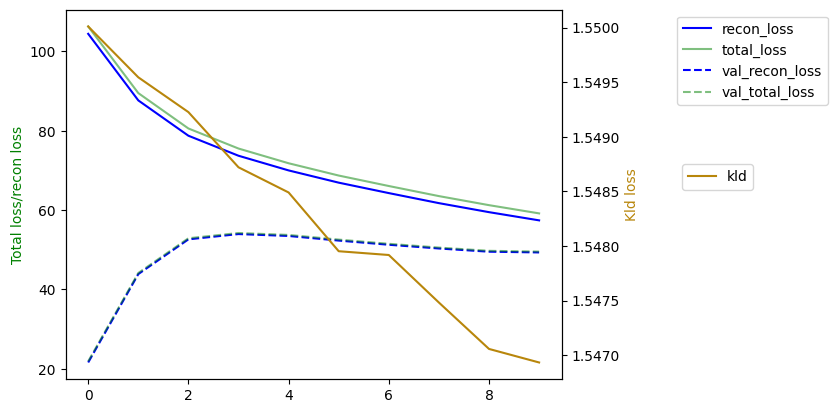

<Figure size 640x480 with 0 Axes>

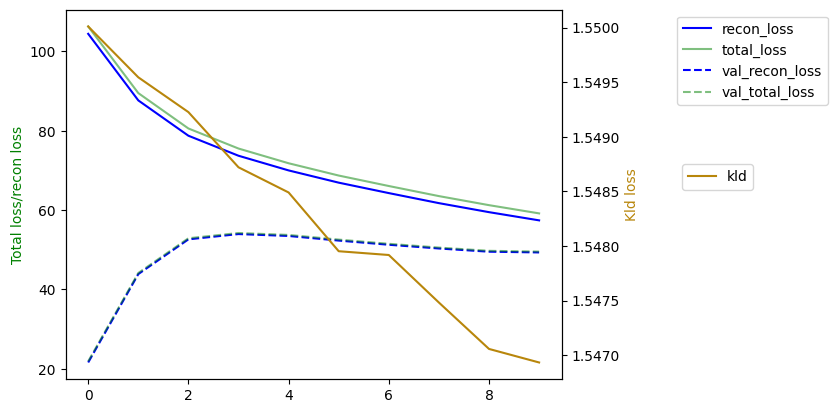

In [ ]:
scmedalre_asd = train_model_on_named_experiment("scMEDAL-RE", "AML", model_kwargs={"n_latent_dims":50}, train_kwargs={"quick":True})

## Analyzing Models:

In [2]:
from importlib import reload
import analysis.analysis as aa
reload(aa)
import analysis.analysis as aa

analysis_name = "AML_default"
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-07_17-56",
}
batches = ["AML420B", "BM5", "MUTZ3"]
celltype = ["Mono", "Mono-like"]

aml = aa.AMLAnalysis(model_folder_dict, analysis_name)

aml_cluster = aml.clustering_scores(model_folder_dict)
aml_geno = aml.genomap(model_folder_dict, batches=batches, types=['train'], splits=[2])
aml_umap = aml.umap(model_folder_dict, types=["train"], splits=[2])


Directory created or already exists: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/compare_models/log_transformed_2916hvggenes/AML_default
ae /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/latent_space/log_transformed_2916hvggenes/ae/run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-07_17-56


Mean scores paths:
  sample_size                                               path model_name
0       10000  /endosome/archive/bioinformatics/DLLab/src/Aus...         ae
ae /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/AML/latent_space/log_transformed_2916hvggenes/ae/run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-

IndexError: index 0 is out of bounds for axis 0 with size 0

In [2]:
from importlib import reload
import analysis.analysis as aa
reload(aa)
import analysis.analysis as aa
analysis_name = "ASD_default"
model_folder_dict = {
    #"ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-07_17-56",    
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-46",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-48",
}
celltype = ["L2/3"]
batches = ["donor_5531","donor_5945", "donor_5419", "donor_6032", "donor_5242",  "donor_5976"]

asd = aa.ASDAnalysis(model_result_folder_dict=model_folder_dict, analysis_name=analysis_name,experiment_name= "ASD")


#asd_cluster = asd.clustering_scores(model_folder_dict)
#asd_geno = asd.genomap(model_folder_dict, batches=batches, types=['train'], splits=[1], cell_id_col="cell", celltype=celltype, num_iter=2)
asd_umap = asd.umap(model_folder_dict, types=["train"], splits=[1])

{'scmedalfe': '/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-46', 'scmedalre': '/endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed_2916hvggenes/scmedalre/run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-48'}
Directory does not exist: /endosome/archive/bioinformatics/DLLab/src/AustinMarckx/git/scMEDAL_for_scRNAseq/outputs/ASD/latent_space/log_transformed_2916hvggenes/scmedalfe/run_crossval_loss_gen_weight-1_loss_recon_weight-4000_los

/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/archive/bioinformatics/DLLab/shared/CondaEnvironments/scMEDAL/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


plotting latent representation: X_umap
plotting latent representation: X_umap
plotting latent representation: X_umap
I broke
plotting latent representation: X_umap
plotting latent representation: X_umap
plotting latent representation: X_umap


KeyError: 'donor_5879'

In [ ]:
from importlib import reload
import analysis.analysis as aa
reload(aa)
import analysis.analysis as aa
analysis_name = "HH_default"
model_folder_dict = {
    "ae":"run_crossval_n_latent_dims-2_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-ae_batch_size-512_epochs-500_patience-30_compute_latents_callback-False_sample_size-10000_n_components-50_get_cf_batch-False_2025-07-07_17-56",    
    "scmedalfe":"run_crossval_loss_gen_weight-1_loss_recon_weight-4000_loss_class_weight-1_n_latent_dims-50_layer_units-512-132_use_batch_norm-True_scaling-min_max_model_type-scmedalfe_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_11-36",
    "scmedalre":"run_crossval_loss_recon_weight-110.0_loss_latent_cluster_weight-0.1_n_latent_dims-50_layer_units-512-132_kl_weight-0.0_scaling-min_max_batch_size-512_epochs-500_patience-30_sample_size-10000_2025-07-08_12-16",

}
celltype = ["Ventricular_Cardiomyocyte", "Endothelial", "Fibroblast", "Pericytes"]
batches = ["H0037_Apex", "HCAHeart7836681", "HCAHeart8102861", "H0015_septum"]

hh = aa.HHAnalysis(model_result_folder_dict=model_folder_dict, analysis_name=analysis_name,experiment_name="HH")

hh_cluster = hh.clustering_scores(model_folder_dict)
hh_geno = hh.genomap(model_folder_dict, batches=batches, types=['train'], splits=[1], cell_id_col="cell", celltype=celltype, num_iter=2)
hh_umap = hh.umap(model_folder_dict, types=["train"], splits=[1])